
---

# ***`Outlier Detection and Removal using the IQR Method`***

- This method is only applicable when the distribution of the data is `skewed`.
- For Normal Distribution we use `Z-Score Method`.

---


![IQR](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*0MPDTLn8KoLApoFvI0P2vQ.png)

#### **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings("ignore")

#### **Load the Dateset**

In [2]:
df = pd.read_csv(r'https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day42-outlier-removal-using-zscore/placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


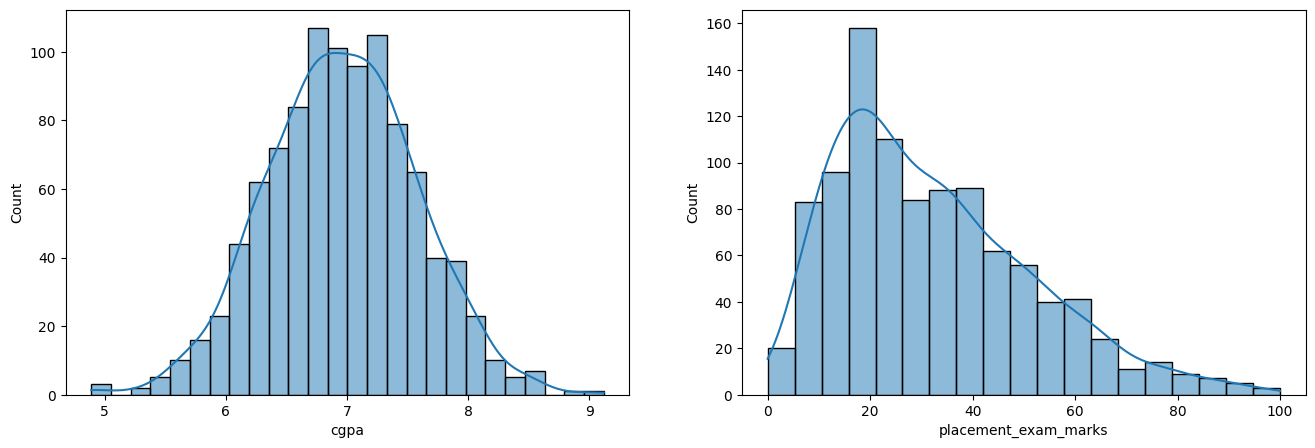

In [3]:
# plot the distribution
plt.figure(figsize=(16, 5))

# Histogram for CGPA
plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)  # kde=True adds the kernel density estimate

# Histogram for Placement Exam Marks
plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)

plt.show()

In [5]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

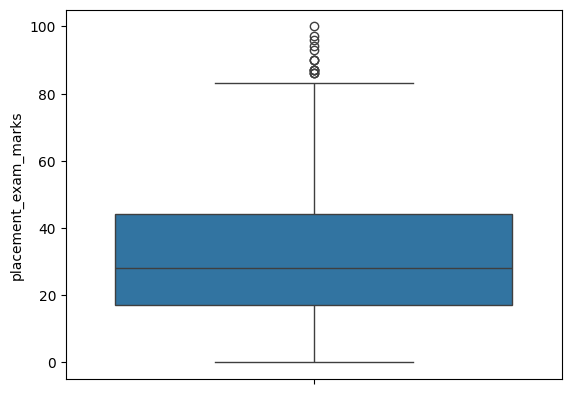

In [6]:
sns.boxplot(df['placement_exam_marks'])
plt.show()

In [7]:
# Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [8]:
percentile25,percentile75

(17.0, 44.0)

### **Calculate IQR**

In [9]:
iqr = percentile75 - percentile25

In [10]:
iqr

27.0

### **Calculate upper_limit AND lower_limit**

In [11]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [12]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 84.5
Lower limit -23.5


### **Finding Outliers**

In [13]:
df[df['placement_exam_marks'] > upper_limit]


,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [14]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed



### **Trimming**

In [15]:
new_df = df[df['placement_exam_marks'] < upper_limit]

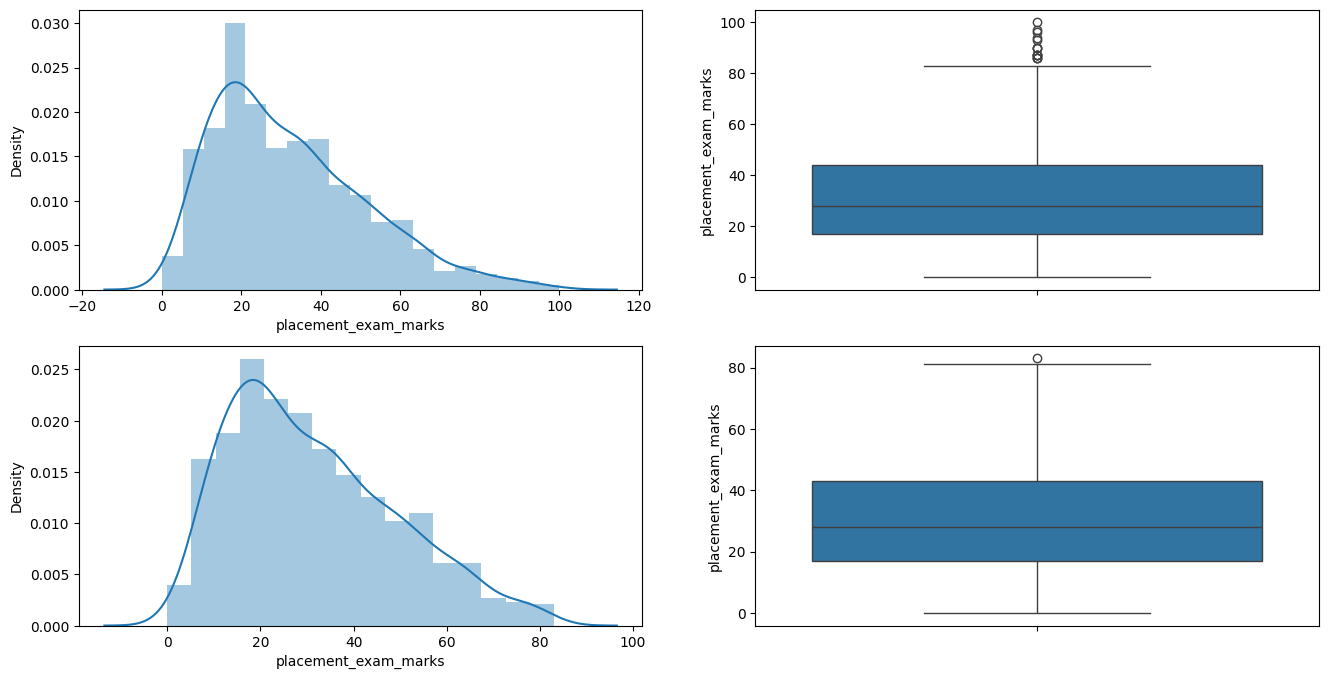

In [16]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

plt.show()

### **Capping**

In [17]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

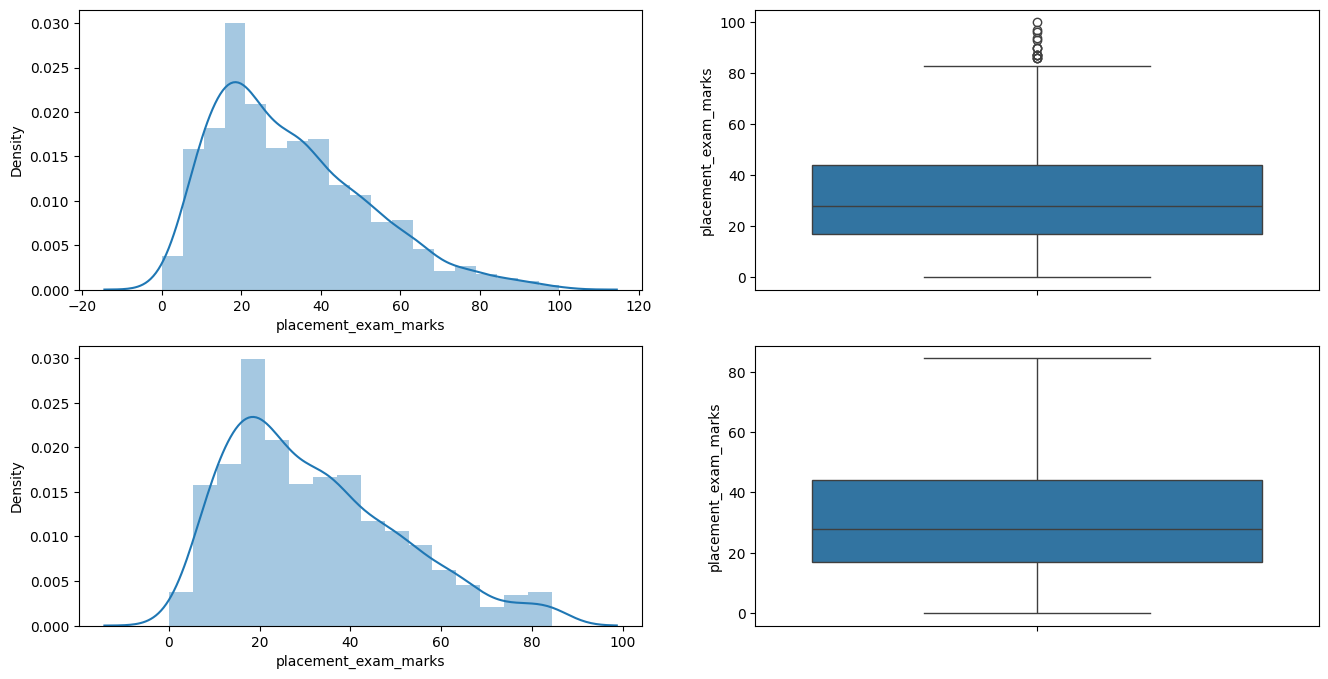

In [19]:

# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()

---